In [1]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import SAGEConv, GraphConv, GraphSAGE
import torch
import networkx as nx 
from torch.utils.data import Dataset, DataLoader
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'sim'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from ClassGraphDat import GraphDataset
torch.manual_seed(42)

In [2]:
class GraphEncoderWithResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphEncoderWithResidual, self).__init__()
        # self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow='target_to_source', root_weight=False)
        # self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow='target_to_source', root_weight=False)
        # self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow='target_to_source', root_weight=False)
        self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow='source_to_target', root_weight=False)
        self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow='source_to_target', root_weight=False)
        self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow='source_to_target', root_weight=False)
        self.lin1 = nn.Linear(hidden_channels, int(hidden_channels/2))
        self.lin2 = nn.Linear(int(hidden_channels/2), out_channels)
        # Linear transformation to match dimensions for residual connection
        self.shortcut = nn.Linear(in_channels, out_channels)
        # self.sm = nn.Softmax(dim=1)

    def forward(self, x, edge_index):
        identity = x
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        x = F.dropout(F.relu(self.lin1(x)), p=0.2)
        x = self.lin2(x)
        # Applying shortcut and adding it to the output of conv3
        identity = self.shortcut(identity)
        x += identity  # Element-wise addition
        # x = self.sm(x)
        return x

In [24]:
def round_function(x, d):
    new = []
    for r in x:
        new.append(np.round(r,decimals=d))
    # pdb.set_trace()
    return tuple(new)

In [3]:
# Assuming a loss function appropriate for node feature reconstruction, e.g., MSE for continuous features
def loss_function(reconstructed_x, original_x):
    # weights = torch.tensor([  2204787.0/14022   ,2204787.0/35079,  2204787.0/780448 ,2204787.0/1375238], dtype=torch.float)
    total = 1.0#2204689.0
    # arr = [1410221,  794468] 
    arr = [1.0, 1.0]
    weights = torch.tensor([total/a for a in arr], dtype = torch.float)
    
    weights = weights/torch.sum(weights)
    # return F.cross_entropy(reconstructed_x, original_x, weight=weights, label_smoothing=0.2)
    # return F.cross_entropy(reconstructed_x, original_x, label_smoothing=0.4)
    return F.cross_entropy(reconstructed_x, original_x, weight=weights)
    # return F.cross_entropy(reconstructed_x, original_x)#/scale#, label_smoothing=0.4)   

In [30]:
def train(model, dataloader, optimizer, device, timeclasses):
    
    model.train()
    total_loss = 0
    embeddings = []
    origs = []
    # lossfunc = nn.CrossEntropyLoss()
        # print(data_loader)
    printlosses = []
        # for dat in data_loader:
    for feat, edge in dataloader:
        optimizer.zero_grad()
        # pdb.set_trace()
        # print(np.shape(feat), np.shape(edges))
        # print('in main: ', np.shape(feat), np.shape(edges))
        features = feat.squeeze_(0).to(device)
        # globalInfo = glob.squeeze_(0).to(device)
        edges = edge.squeeze_(0).to(device)
        # embed = model(torch.cat([globalInfo, features], dim=1), edges)
        embed = model(features, edges)

        origs.append(features.detach())
        classes = []
        for feat in features:
            # pdb.set_trace()
            classes.append(timeclasses[tuple(round_function(feat.detach().tolist(), 3))]) #torch.tensor(dat[2], dtype = torch.long)
        # class_now = get_class(meta, n)
        # print(np.shape(nodes), np.shape(edges), np.shape(class_now))
        # try:
        #     if n.dim() == 1:
        #         n = n.unsqueeze(1)

        # embed = model(features, edges)

        # except Exception as e:
        #     pdb.set_trace()

        # print(len(data[0][0]))
        # pdb.set_trace()
        # print(np.shape(class_now), class_now)
        # if np.mean(class_now.tolist()) < 0.01:
        # pdb.set_trace()
        loss = loss_function(embed, torch.tensor(classes, dtype = torch.long)) #cosine_loss(data[1][0].to(device), embed)
        # loss = cosine_loss(embed, classes) 
        # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        loss.backward()
        optimizer.step()
        total_loss += loss.detach().item()
        printlosses.append(loss.detach().item())
        if len(printlosses)%1000 == 0:
            printlosses = printlosses[-1000:]
            print(np.sum(printlosses)/1000.0)
        # embeddings.append(embed.detach())
        # print(total_loss)/10.0
    return total_loss / len(dataloader), embeddings, origs

In [5]:
folder_graph = './'
device = "cpu"
# fname = 'small_graphs.pth'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle')]
# files = ['alledges', 'allsucc', 'alltime', 'edgesList', 'nodeIDs']
hC = 15
inC = 40
outchannels = 2

In [6]:

fil2 = open('MULTIPLEalltime.pickle', 'rb')
times = pickle.load(fil2)
fil2.close()

# fil2 = open('allsucc.pickle', 'rb')
# successes = pickle.load(fil2)
# fil2.close()

# fil2 = open('edgeList.pickle', 'rb')
# edges = pickle.load(fil2)
# fil2.close()

# fil2 = open('nodeIDs.pickle', 'rb')
# nodes = pickle.load(fil2)
# fil2.close()

meanTimes = dict()
for n in times:
    meanTimes[n] = np.mean(times[n])

In [27]:
TIME_LIMIT =  400

# def round_function(x, d):
#     new = []
#     for r in x:
#         new.append(np.round(r,decimals=d))
#     # pdb.set_trace()
#     return tuple(new)

def get_class(a):
    if a > TIME_LIMIT:
        return 0
        retVal = torch.tensor(0, dtype=torch.long)
        return retVal
    else:
        return 1
        retVal = torch.tensor(1, dtype=torch.long)
        return retVal
    # arr = []
    # if a > TIME_LIMIT:
    #     arr.append(0)
    # else:
    #     arr.append(1)

    # try:
    #     retVal = torch.tensor(arr, dtype=torch.long)
    #     return retVal
    # except:
    #     pdb.set_trace()
    # edges

In [28]:
timeClasses = dict()
for n in meanTimes:
    timeClasses[n] = get_class(meanTimes[n])

# times_ = []
# for t in timeClasses.values():
#     times_.append(t)


In [9]:

# nodesList = []
# for n in nodes:
#     nodesList.append(n)

In [10]:


# dataset = GraphDataset(folder_graph, files)
# dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)
actuals = []
final_loss = []
embeddings = []
fg = './finishedall/'
files = os.listdir(fg)
files = [file for file in files if file.endswith('.pickle')]
dataset = GraphDataset(fg, files)#, meta)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)

# dataloader=
# dataloader = [torch.tensor(times_, dtype=torch.long).to(device), torch.tensor(nodesList, dtype=torch.float).to(device), torch.tensor(edges, dtype=torch.long).t().to(device)]
model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.11)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
losses = []
embeds = []
acts = []
# timeclasses = torch.tensor(times_, dtype=torch.long).to(device)

In [11]:
# dataloader[2]
# np.shape(dataloader[2].t())

In [31]:


for epoch in range(1, 5):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device, timeClasses)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# epoch_loss = loss / len(dataloader)
# embeddings.append(embeds)
# final_loss.append(losses)
# actuals.append(acts)
model.eval()
# Assuming encoder and decoder are your model's components
encoder_state_dict = model.state_dict()
# decoder_state_dict = model.decoder.state_dict()
# Save the state dictionaries
torch.save(encoder_state_dict, './ALLTime_encoder_state_dict'+str(outchannels)+'.pth')
# torch.save(decoder_state_dict, './CDC/decoder_state_dict'+str(outchannels)+'.pth')
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))


0.5788685083603522
0.49327346390538185
0.5929357773081187
0.46042799957982483
0.5253847450767131
0.5660827712393662
0.5343531845593639
0.5789841516124483
0.5200734100335012
0.5438027371705018
0.5243440592923709
0.4925956644394159
0.5971649119220533
0.566614929520715
0.48618621861283223
0.6037266645350967
0.4999132767212695
0.5903626677695206
0.4736838249114874
0.6530473006130769
0.5133239345437042
0.5064728941688313
0.5267974417059119
0.567005084569985
0.46824488564712724
0.5364961356283465
0.6056264789686376
0.5399916293954318
0.5642191037606074
0.6165567795335681
0.5780452222260767
0.5229660857842343
0.5448324038545211
0.5055190783910437
0.5457996285180569
0.57651650560025
0.5643162735611638
0.7164050949801571
0.5141371558097965
0.5934496203287692
0.5482057372515164
0.5413559802295574
0.524858321974187
0.6405182923978928
0.51330671020752
0.6000627460156533
0.523265965510636
0.5859226878592456
0.5453037042932838
0.5770960961675667
Epoch 1, Loss: 0.5533
0.5787629948891364
0.45374336013

In [32]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1, 5):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device, timeClasses)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
model.eval()
encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './ALLTime_encoder_state_dict'+str(outchannels)+'.pth')


0.39116995103052626
0.3266456287752648
0.3238679791682946
0.3504166231518126
0.3222833759694847
0.3169321036044028
0.29494167812624666
0.28854782818869457
0.3285397125252516
0.28963108265863935
0.31850211905621784
0.3177019903678931
0.2632391965111155
0.26067134606614784
0.30648398581401765
0.2772636128767707
0.2699305961606481
0.29604199837220535
0.2742271882204665
0.27411610811811016
0.2869713053685885
0.27463132863687206
0.26565805200904785
0.27572209887786897
0.28568486615798516
0.2685877672913849
0.27957977381290333
0.26288936259456525
0.2601953227037534
0.2835743038033762
0.2924508726194384
0.2803974513629763
0.2838519099891738
0.3006724195700859
0.2956125618764512
0.2576114352716065
0.2525246311237558
0.2717510360496202
0.29234959508364844
0.26377332832468553
0.26645715701443856
0.25689163260860703
0.2944958645956276
0.2757536404284268
0.24995863090282808
0.2463966519843546
0.27055955495074263
0.27547618138547514
0.25381477013034964
0.23470855339681135
Epoch 1, Loss: 0.2847
0.26

RuntimeError: Shared memory manager connection has timed out

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(1, 5):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device, timeClasses)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
model.eval()
encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './ALLTime_encoder_state_dict'+str(outchannels)+'.pth')

Epoch 1, Loss: 0.1571
Epoch 2, Loss: 0.1571
Epoch 3, Loss: 0.1571
Epoch 4, Loss: 0.1571
Epoch 5, Loss: 0.1570
Epoch 6, Loss: 0.1570
Epoch 7, Loss: 0.1570
Epoch 8, Loss: 0.1570
Epoch 9, Loss: 0.1570
Epoch 10, Loss: 0.1569
Epoch 11, Loss: 0.1569
Epoch 12, Loss: 0.1569
Epoch 13, Loss: 0.1569
Epoch 14, Loss: 0.1568
Epoch 15, Loss: 0.1568
Epoch 16, Loss: 0.1568
Epoch 17, Loss: 0.1568
Epoch 18, Loss: 0.1567
Epoch 19, Loss: 0.1567
Epoch 20, Loss: 0.1567
Epoch 21, Loss: 0.1567
Epoch 22, Loss: 0.1567
Epoch 23, Loss: 0.1566
Epoch 24, Loss: 0.1566
Epoch 25, Loss: 0.1566
Epoch 26, Loss: 0.1566
Epoch 27, Loss: 0.1565
Epoch 28, Loss: 0.1565
Epoch 29, Loss: 0.1565


In [ ]:
# optimizer = optim.Adam(model.parameters(), lr=0.0001)

# for epoch in range(1, 5):  # Number of epochs
#     loss, embed, orig = train(model, dataloader, optimizer, device)
#     # embeds.append(embed)
#     # acts.append(orig)
#     print(f'Epoch {epoch}, Loss: {loss:.4f}')
#     # losses.append(loss)
# model.eval()
# encoder_state_dict = model.state_dict()
# torch.save(encoder_state_dict, './ALLTime_encoder_state_dict'+str(outchannels)+'.pth')

Epoch 1, Loss: 0.1565
Epoch 2, Loss: 0.1565
Epoch 3, Loss: 0.1565
Epoch 4, Loss: 0.1565
Epoch 5, Loss: 0.1565
Epoch 6, Loss: 0.1565
Epoch 7, Loss: 0.1565
Epoch 8, Loss: 0.1564
Epoch 9, Loss: 0.1564
Epoch 10, Loss: 0.1564
Epoch 11, Loss: 0.1564
Epoch 12, Loss: 0.1564
Epoch 13, Loss: 0.1564
Epoch 14, Loss: 0.1564
Epoch 15, Loss: 0.1564
Epoch 16, Loss: 0.1564
Epoch 17, Loss: 0.1564
Epoch 18, Loss: 0.1564
Epoch 19, Loss: 0.1564
Epoch 20, Loss: 0.1564
Epoch 21, Loss: 0.1564
Epoch 22, Loss: 0.1564
Epoch 23, Loss: 0.1564
Epoch 24, Loss: 0.1564
Epoch 25, Loss: 0.1564
Epoch 26, Loss: 0.1564
Epoch 27, Loss: 0.1564
Epoch 28, Loss: 0.1564
Epoch 29, Loss: 0.1564


In [ ]:
# GAE = GraphEncoderWithResidual(inC, hC, outchannels)
# import pickle
import numpy as np
import torch


from collections import defaultdict 

encoder_dict = torch.load('./ALLTime_encoder_state_dict2.pth')


In [ ]:

GAE = GraphEncoderWithResidual(inC, hC, outchannels)
GAE.load_state_dict(encoder_dict)
emb = []
# arrtosave = []

In [ ]:
# print(np.shape(torch.tensor([nodesList[0]], dtype=torch.float)), np.shape(torch.tensor([[],[]], dtype=torch.long)))
# GAE(torch.tensor([nodesList[0]], dtype=torch.float), torch.tensor([[],[]], dtype=torch.long))


torch.Size([1, 40]) torch.Size([2, 0])


In [ ]:

# for i in arr1: 
GAE.eval()
emb = []
for ii in nodesList: 
    # break
# GAE(torch.tensor([ast.literal_eval(i)], dtype=torch.float), torch.empty((2,0), dtype=torch.int64).detach().tolist()[0])
    try:
        # pdb.set_trace()
        emb.append(GAE(torch.tensor([ii], dtype=torch.float), torch.tensor([[],[]], dtype=torch.long)).detach().tolist()[0])
        # arrtosave.append(i) 
    except Exception as e:
        print(e)
        print(np.shape(ii))

In [ ]:
times_
times_check = []
for t in times_:
    times_check.append(t.tolist())

In [ ]:
# import numpy as np
# from scipy.special import expit, logit
# emb
# newembs = []
# for e in emb:
#     newembs.append(expit(e))

# newembs
# emb

In [ ]:
print(np.shape(times_check), np.shape(emb))

y_true_indices = times_check#np.argmax(times_check, axis=1)
y_pred_indices = np.argmax(emb, axis=1)
# print(np.argmax(emb, axis=1)[0:10])
# print(np.argmax(arrclass, axis=1)[0:10])


(88568,) (88568, 2)


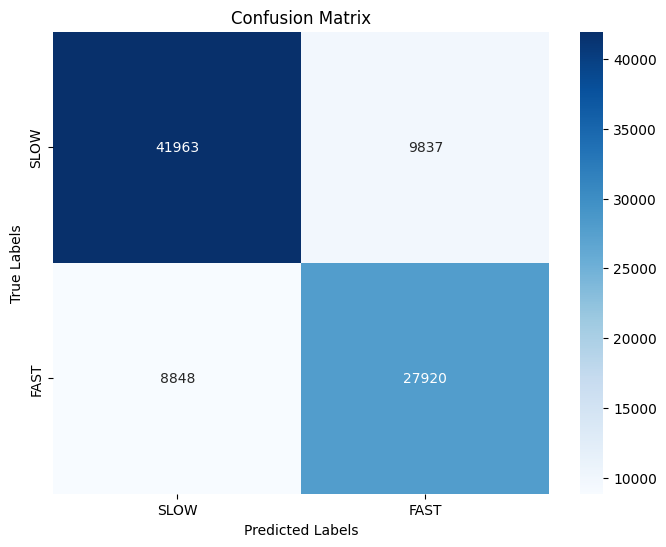

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
cm = confusion_matrix(y_true_indices, y_pred_indices)
# ConfusionMatrixDisplay(cm).plot()
# CLIST =  ["Fast/Failure", "Slow/Failure", "Fast/Success", "Slow/Success"]

CLIST =  ["SLOW", "FAST"]
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
# 

In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

In [ ]:
print('roc auc score: ', roc_auc_score(y_true_indices, y_pred_indices))
print('precision score: ', precision_score(y_true_indices, y_pred_indices))
print('recall score: ', recall_score(y_true_indices, y_pred_indices))
print('f1 score: ', f1_score(y_true_indices, y_pred_indices))
print('accuracy score: ', accuracy_score(y_true_indices, y_pred_indices))


roc auc score:  0.7847262434011781
precision score:  0.7394655295706757
recall score:  0.7593559617058312
f1 score:  0.7492787655149278
accuracy score:  0.7890321560834613


10:

roc auc score:  0.7847262434011781
precision score:  0.7394655295706757
recall score:  0.7593559617058312
f1 score:  0.7492787655149278
accuracy score:  0.7890321560834613

5: 

roc auc score:  0.7807121435124047
precision score:  0.7352067868504772
recall score:  0.7542428198433421
f1 score:  0.7446031575555795
accuracy score:  0.7852045885647186

In [ ]:


# print(np.sum([1 for y in y_true_indices if y == 1]))
# total = np.sum(cm, axis=1)
# print(total, np.sum(total))
# print(cm)
# 0: 14022, 1: 35079, 2: 780448 1375238

In [ ]:
# import torch
# import statistics
# arr = []
# for a in meta:
#     arr.append(statistics.mean(meta[a]))

# times_ = []
# for t in timeClasses.values():
#     times_.append(t)
# # print(n)
# import matplotlib.pyplot as plt
# x=plt.hist(times_)
# plt.xlim([0,200])


# import shutil
# import os
# import numpy as np
# import pandas as pd
# from ast import literal_eval
# from collections import defaultdict
# def other():
#     folder = '../../graphsage_results/CDC/multiple_agent_env_results/'
#     files = os.listdir(folder)
#     files = [file for file in files if file.endswith('.csv') and file.startswith('1')]
#     files = np.sort(files)
#     # data_files = []
#     metadata_file = folder + 'metadata.csv'
#     # folder_graph = './graphs/RS/fast_multiple_graphs/'
#     # new_metadata_file = folder_graph + 'metadata.csv'
#     # graph_metaFile = 'graphMetadata.csv'
#     # meta_arr = []
#     metadata = pd.read_csv(metadata_file) 
#     metadata.site_qualities=metadata.site_qualities.apply(literal_eval)
#     metadata.site_positions=metadata.site_positions.apply(literal_eval)
#     metadata.site_positions=metadata.site_positions.apply(lambda x: tuple([tuple(a) for a in x]))
#     metadata.site_qualities=metadata.site_qualities.apply(lambda x: tuple(x))
#     df = metadata.groupby(by=['site_qualities', 'site_positions', 'num_agents'], as_index=False).agg(lambda x: x.tolist())
#     Gtime = defaultdict(list)
#     Gsucc = defaultdict(list)
#     Gedge = defaultdict(defaultdict)
    
#     for some_id, entry in enumerate(df.iterrows()):
#         # copy files
#         for file in entry[1].iloc[3]:
#             shutil.copyfile(folder+file, '../../oneGraphFiles/'+file)
#         break

# other()